# 18. Stable Diffusion Inpainting Restoration

This notebook generates Stable Diffusion Inpainting restoration outputs for the controlled 50-painting subset.

The model is evaluated as a diffusion-based generative inpainting baseline after OpenCV Telea and LaMa.

The notebook uses the same synthetic damage metadata as the previous restoration baselines and produces restoration metadata compatible with the existing metric pipeline.

## Restoration strategy

Stable Diffusion Inpainting is prompt-conditioned and generative. To reduce prompt-engineering bias, this notebook uses one fixed restoration prompt for all paintings.

Non-zero damage cases are processed through Stable Diffusion Inpainting.

Zero-control cases are copied directly from the damaged input to the restored output, matching the policy used for LaMa. This avoids asking the model to inpaint an image with no damaged pixels.

The model inference resolution is set to 512 × 512 for memory stability on the available GPU. Final restored outputs are resized back to the processed image size so that downstream metrics remain comparable with OpenCV Telea and LaMa.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from restoration_eval.restoration_stable_diffusion import (
    DEFAULT_NEGATIVE_PROMPT,
    DEFAULT_PROMPT,
    HF_MODEL_ID,
    MODEL_NAME,
    ZERO_CONTROL_MASK_TYPE,
    get_device,
    load_stable_diffusion_inpaint_pipeline,
    run_stable_diffusion_restoration_pipeline,
    run_stable_diffusion_single_case,
    summarize_stable_diffusion_restoration_metadata,
    validate_stable_diffusion_restoration_outputs,
)

print("Project root:", PROJECT_ROOT)
print("Model name:", MODEL_NAME)
print("HF model id:", HF_MODEL_ID)

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Model name: stable_diffusion_inpainting
HF model id: runwayml/stable-diffusion-inpainting


In [2]:
config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]

processed_metadata_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

damaged_metadata_path = processed_metadata_dir / "metadata_damaged_images.csv"
restored_output_dir = PROJECT_ROOT / "data" / "processed" / "restored" / MODEL_NAME
restored_metadata_path = processed_metadata_dir / "metadata_restored_stable_diffusion.csv"

overview_summary_path = metrics_dir / "stable_diffusion_restoration_overview_summary_50.csv"
by_mask_type_summary_path = metrics_dir / "stable_diffusion_restoration_by_mask_type_summary_50.csv"
by_inference_mode_summary_path = metrics_dir / "stable_diffusion_restoration_by_inference_mode_summary_50.csv"
validation_summary_path = metrics_dir / "stable_diffusion_restoration_validation_summary_50.csv"
visual_inspection_manifest_path = metrics_dir / "stable_diffusion_selected_visual_inspection_manifest_50.csv"

visual_inspection_dir = figures_dir / "stable_diffusion_restoration_selected_cases"
visual_inspection_dir.mkdir(parents=True, exist_ok=True)

print("Damaged metadata:", damaged_metadata_path)
print("Restored output dir:", restored_output_dir)
print("Restored metadata:", restored_metadata_path)
print("Visual inspection dir:", visual_inspection_dir)

Damaged metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_damaged_images.csv
Restored output dir: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\stable_diffusion_inpainting
Restored metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_stable_diffusion.csv
Visual inspection dir: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\stable_diffusion_restoration_selected_cases


In [3]:
device = get_device(prefer_cuda=True)

seed = 2026
num_inference_steps = 30
guidance_scale = 7.5
inference_size = 512

prompt = DEFAULT_PROMPT
negative_prompt = DEFAULT_NEGATIVE_PROMPT

print("Selected device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
    print(
        "Allocated VRAM before loading:",
        round(torch.cuda.memory_allocated() / 1024**3, 3),
        "GB",
    )
    print(
        "Reserved VRAM before loading:",
        round(torch.cuda.memory_reserved() / 1024**3, 3),
        "GB",
    )

print("\nPrompt:")
print(prompt)

print("\nNegative prompt:")
print(negative_prompt)

print("\nInference settings:")
print("seed:", seed)
print("num_inference_steps:", num_inference_steps)
print("guidance_scale:", guidance_scale)
print("inference_size:", inference_size)

Selected device: cuda
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060 Laptop GPU
Allocated VRAM before loading: 0.0 GB
Reserved VRAM before loading: 0.0 GB

Prompt:
restore the missing damaged area of the painting, preserve the original style, colors, brushwork, composition, and surrounding visual context

Negative prompt:
modern objects, text, watermark, signature, frame, border, people added, face changed, extra objects, oversharpened, cartoon, digital art, photorealistic, unrealistic texture

Inference settings:
seed: 2026
num_inference_steps: 30
guidance_scale: 7.5
inference_size: 512


In [4]:
if not damaged_metadata_path.exists():
    raise FileNotFoundError(f"Damaged metadata not found: {damaged_metadata_path}")

damaged_metadata_df = pd.read_csv(damaged_metadata_path)

print("Damaged metadata shape:", damaged_metadata_df.shape)
display(damaged_metadata_df.head())

print("\nMask type counts:")
display(damaged_metadata_df["mask_type"].value_counts().sort_index())

print("\nStatus counts:")
display(damaged_metadata_df["status"].value_counts(dropna=False))

Damaged metadata shape: (250, 19)


,case_id,painting_id,mask_id,mask_type,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,damage_fill_strategy,damage_fill_r,damage_fill_g,damage_fill_b,damaged_area_pixels,damaged_area_percentage_content,damaged_area_percentage_full,status,issue
0,p001_loss_large,p001,p001_loss_large,loss_large,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,67242,13.2058,11.4003,ok,NaN
1,p001_loss_small,p001,p001_loss_small,loss_small,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,24198,4.7523,4.1026,ok,NaN
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,44392,8.7183,7.5263,ok,NaN
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,8012,1.5735,1.3584,ok,NaN
4,p001_zero_control,p001,p001_zero_control,zero_control,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,white_fill,255,255,255,0,0.0000,0.0000,ok,NaN



Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64


Status counts:


status
ok    250
Name: count, dtype: int64

In [5]:
required_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "clean_path",
    "damaged_path",
    "mask_path",
    "status",
]

missing_columns = [
    column for column in required_columns
    if column not in damaged_metadata_df.columns
]

if missing_columns:
    raise ValueError(f"Damaged metadata missing required columns: {missing_columns}")

if len(damaged_metadata_df) != 250:
    raise ValueError(
        f"Expected 250 damaged metadata rows, found {len(damaged_metadata_df)}."
    )

if damaged_metadata_df["case_id"].duplicated().any():
    duplicated_cases = damaged_metadata_df[
        damaged_metadata_df["case_id"].duplicated(keep=False)
    ]
    display(duplicated_cases)
    raise ValueError("Damaged metadata contains duplicate case_id values.")

non_ok_count = int((damaged_metadata_df["status"] != "ok").sum())

if non_ok_count != 0:
    display(damaged_metadata_df[damaged_metadata_df["status"] != "ok"].head(20))
    raise ValueError(f"Damaged metadata contains {non_ok_count} non-ok rows.")

expected_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_mask_counts = damaged_metadata_df["mask_type"].value_counts().to_dict()

print("Expected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

def resolve_project_path(path_value: str | Path) -> Path:
    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path

for path_column in ["clean_path", "damaged_path", "mask_path"]:
    missing_paths = [
        resolve_project_path(path)
        for path in damaged_metadata_df[path_column]
        if not resolve_project_path(path).exists()
    ]

    print(path_column, "missing files:", len(missing_paths))

    if missing_paths:
        raise FileNotFoundError(
            f"Missing files in {path_column!r}: {missing_paths[:10]}"
        )

print("\nStable Diffusion input metadata gates passed.")

Expected mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
clean_path missing files: 0
damaged_path missing files: 0
mask_path missing files: 0

Stable Diffusion input metadata gates passed.


In [6]:
smoke_nonzero_df = (
    damaged_metadata_df[
        damaged_metadata_df["mask_type"] != ZERO_CONTROL_MASK_TYPE
    ]
    .sort_values(["painting_id", "mask_type"])
    .head(1)
    .copy()
)

smoke_zero_control_df = (
    damaged_metadata_df[
        damaged_metadata_df["mask_type"] == ZERO_CONTROL_MASK_TYPE
    ]
    .sort_values(["painting_id", "mask_type"])
    .head(1)
    .copy()
)

smoke_cases_df = pd.concat(
    [smoke_nonzero_df, smoke_zero_control_df],
    ignore_index=True,
)

print("Smoke-test cases:")
display(
    smoke_cases_df[
        [
            "case_id",
            "painting_id",
            "mask_id",
            "mask_type",
            "clean_path",
            "damaged_path",
            "mask_path",
        ]
    ]
)

if len(smoke_cases_df) != 2:
    raise ValueError(f"Expected 2 smoke-test cases, found {len(smoke_cases_df)}.")

if smoke_cases_df["mask_type"].eq(ZERO_CONTROL_MASK_TYPE).sum() != 1:
    raise ValueError("Smoke-test cases must include exactly one zero-control case.")

if smoke_cases_df["mask_type"].ne(ZERO_CONTROL_MASK_TYPE).sum() != 1:
    raise ValueError("Smoke-test cases must include exactly one non-zero case.")

print("Smoke-test case selection passed.")

Smoke-test cases:


,case_id,painting_id,mask_id,mask_type,clean_path,damaged_path,mask_path
0,p001_loss_large,p001,p001_loss_large,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_zero_control,p001,p001_zero_control,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


Smoke-test case selection passed.


In [7]:
pipe = load_stable_diffusion_inpaint_pipeline(
    model_id=HF_MODEL_ID,
    device=device,
    enable_attention_slicing=True,
    disable_safety_checker=True,
)

if torch.cuda.is_available():
    print(
        "Allocated VRAM after loading:",
        round(torch.cuda.memory_allocated() / 1024**3, 3),
        "GB",
    )
    print(
        "Reserved VRAM after loading:",
        round(torch.cuda.memory_reserved() / 1024**3, 3),
        "GB",
    )

print("Stable Diffusion pipeline ready.")

Loading Stable Diffusion inpainting pipeline
  Model id: runwayml/stable-diffusion-inpainting
  Device: cuda
  Torch dtype: torch.float16


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\huggingface_hub\file_download.py:147: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in E:\HFCache\hub\models--runwayml--stable-diffusion-inpainting. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mod

Stable Diffusion inpainting pipeline loaded
Allocated VRAM after loading: 2.021 GB
Reserved VRAM after loading: 2.033 GB
Stable Diffusion pipeline ready.


In [8]:
smoke_output_dir = restored_output_dir / "_smoke_test"

smoke_result = run_stable_diffusion_restoration_pipeline(
    smoke_cases_df,
    restored_output_dir=smoke_output_dir,
    project_root=PROJECT_ROOT,
    pipe=pipe,
    device=device,
    model_id=HF_MODEL_ID,
    model_name=MODEL_NAME,
    prompt=prompt,
    negative_prompt=negative_prompt,
    seed=seed,
    num_inference_steps=num_inference_steps,
    guidance_scale=guidance_scale,
    inference_size=inference_size,
    use_relative_paths=True,
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    progress_every=1,
    clear_cuda_cache_every=1,
)

smoke_restoration_df = smoke_result["restoration_metadata_df"]
smoke_run_info = smoke_result["run_info"]

print("Smoke restoration metadata shape:", smoke_restoration_df.shape)
display(
    smoke_restoration_df[
        [
            "case_id",
            "painting_id",
            "mask_type",
            "model_name",
            "inference_mode",
            "restored_path",
            "seed",
            "num_inference_steps",
            "guidance_scale",
            "inference_size",
            "case_runtime_seconds",
            "status",
            "issue",
        ]
    ]
)

print("\nSmoke run info:")
display(pd.DataFrame([smoke_run_info]))

Starting Stable Diffusion restoration pipeline
  Input rows: 2
  Valid working rows: 2
  Non-zero model inference rows: 1
  Zero-control copy rows: 1
  Restored output dir: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\stable_diffusion_inpainting\_smoke_test
  Device: cuda
  Model id: runwayml/stable-diffusion-inpainting
  Prompt: restore the missing damaged area of the painting, preserve the original style, colors, brushwork, composition, and surrounding visual context
  Negative prompt: modern objects, text, watermark, signature, frame, border, people added, face changed, extra objects, oversharpened, cartoon, digital art, photorealistic, unrealistic texture
  Seed: 2026
  Steps: 30
  Guidance scale: 7.5
  Inference size: 512
Running Stable Diffusion case 1/1
Copying Stable Diffusion zero-control outputs directly: 1 cases
Copying zero-control Stable Diffusion output 1/1
Stable Diffusion zero-control copy complete
Stable Diffusion restoration pipeline complete

,case_id,painting_id,mask_type,model_name,inference_mode,restored_path,seed,num_inference_steps,guidance_scale,inference_size,case_runtime_seconds,status,issue
0,p001_loss_large,p001,loss_large,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,13.211524,ok,
1,p001_zero_control,p001,zero_control,stable_diffusion_inpainting,copied_zero_control,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,0.000000,ok,zero_control copied without model inference



Smoke run info:


,model_id,model_name,device,prompt,negative_prompt,seed,num_inference_steps,guidance_scale,inference_size,total_runtime_seconds,nonzero_rows,zero_control_rows
0,runwayml/stable-diffusion-inpainting,stable_diffusion_inpainting,cuda,restore the missing damaged area of the painti...,"modern objects, text, watermark, signature, fr...",2026,30,7.5,512,14.650224,1,1


In [9]:
smoke_validation_df = validate_stable_diffusion_restoration_outputs(
    smoke_restoration_df,
    project_root=PROJECT_ROOT,
    expected_size=(768, 768),
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    progress_every=1,
)

display(smoke_validation_df)

if len(smoke_validation_df) != 2:
    raise ValueError(
        f"Expected 2 smoke validation rows, found {len(smoke_validation_df)}."
    )

if not smoke_validation_df["validation_passed"].all():
    display(smoke_validation_df[~smoke_validation_df["validation_passed"]])
    raise ValueError("Stable Diffusion smoke-test validation failed.")

nonzero_validation_df = smoke_validation_df[
    smoke_validation_df["mask_type"] != ZERO_CONTROL_MASK_TYPE
]

zero_validation_df = smoke_validation_df[
    smoke_validation_df["mask_type"] == ZERO_CONTROL_MASK_TYPE
]

if not bool(nonzero_validation_df["changed_from_damaged"].iloc[0]):
    raise ValueError("Smoke-test non-zero Stable Diffusion output did not change.")

if not bool(zero_validation_df["exact_match_to_damaged"].iloc[0]):
    raise ValueError("Smoke-test zero-control output is not identical to damaged input.")

print("Stable Diffusion smoke-test validation passed.")

Validating Stable Diffusion restored outputs: 2 rows
Validating Stable Diffusion output 1/2
Validating Stable Diffusion output 2/2
Stable Diffusion validation complete
validation_passed
True    2


,case_id,painting_id,mask_type,status,damaged_exists,restored_exists,restored_width,restored_height,restored_mode,exact_match_to_damaged,changed_from_damaged,max_abs_diff,mean_abs_diff,validation_passed,validation_issue
0,p001_loss_large,p001,loss_large,ok,True,True,768,768,RGB,False,True,255.0,27.888373,True,
1,p001_zero_control,p001,zero_control,ok,True,True,768,768,RGB,True,False,0.0,0.000000,True,


Stable Diffusion smoke-test validation passed.


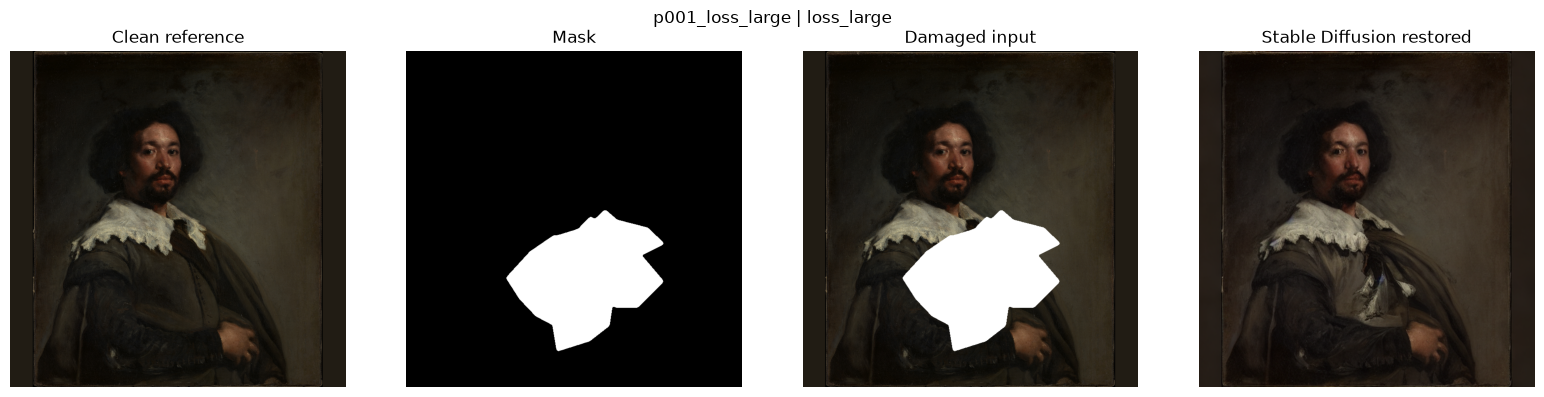

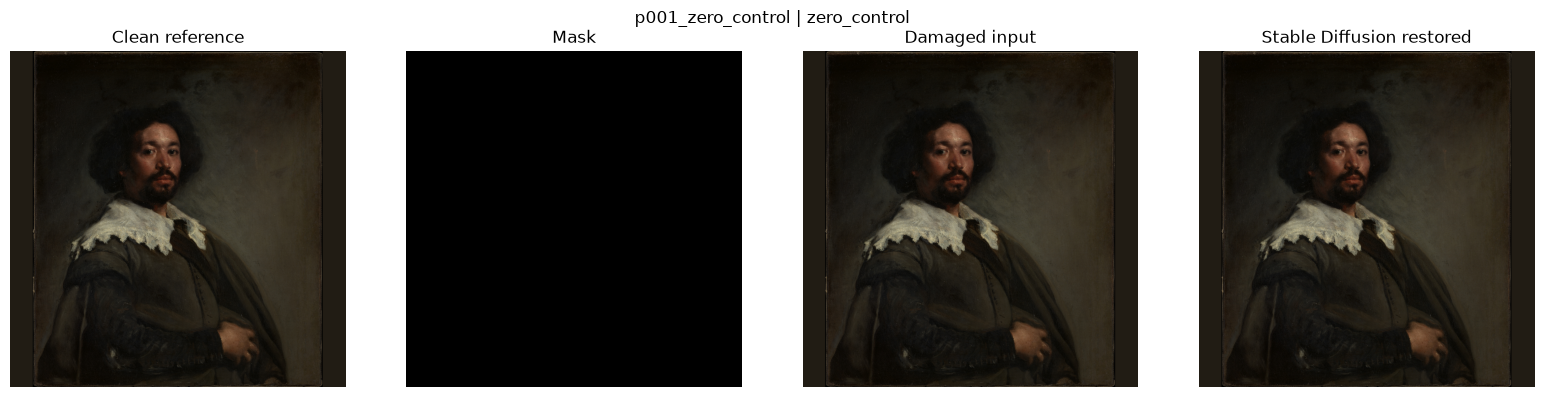

In [10]:
def show_smoke_case(row: pd.Series) -> None:
    clean_path = resolve_project_path(row["clean_path"])
    damaged_path = resolve_project_path(row["damaged_path"])
    mask_path = resolve_project_path(row["mask_path"])
    restored_path = resolve_project_path(row["restored_path"])

    clean_img = Image.open(clean_path).convert("RGB")
    damaged_img = Image.open(damaged_path).convert("RGB")
    mask_img = Image.open(mask_path).convert("L")
    restored_img = Image.open(restored_path).convert("RGB")

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(clean_img)
    axes[0].set_title("Clean reference")
    axes[0].axis("off")

    axes[1].imshow(mask_img, cmap="gray")
    axes[1].set_title("Mask")
    axes[1].axis("off")

    axes[2].imshow(damaged_img)
    axes[2].set_title("Damaged input")
    axes[2].axis("off")

    axes[3].imshow(restored_img)
    axes[3].set_title("Stable Diffusion restored")
    axes[3].axis("off")

    fig.suptitle(f"{row['case_id']} | {row['mask_type']}", fontsize=12)
    plt.tight_layout()
    plt.show()


for _, row in smoke_restoration_df.iterrows():
    show_smoke_case(row)

In [11]:
one_painting_id = (
    damaged_metadata_df["painting_id"]
    .sort_values()
    .iloc[0]
)

one_painting_cases_df = (
    damaged_metadata_df[
        damaged_metadata_df["painting_id"] == one_painting_id
    ]
    .sort_values("mask_type")
    .reset_index(drop=True)
)

print("One-painting test painting_id:", one_painting_id)
print("One-painting test cases:", len(one_painting_cases_df))

display(
    one_painting_cases_df[
        [
            "case_id",
            "painting_id",
            "mask_id",
            "mask_type",
            "clean_path",
            "damaged_path",
            "mask_path",
        ]
    ]
)

expected_one_painting_mask_types = {
    "loss_large",
    "loss_small",
    "mixed_damage",
    "scratch_thin",
    "zero_control",
}

actual_one_painting_mask_types = set(one_painting_cases_df["mask_type"])

if len(one_painting_cases_df) != 5:
    raise ValueError(
        f"Expected 5 one-painting cases, found {len(one_painting_cases_df)}."
    )

if actual_one_painting_mask_types != expected_one_painting_mask_types:
    raise ValueError(
        f"Unexpected one-painting mask types: {actual_one_painting_mask_types}"
    )

print("One-painting test selection passed.")

One-painting test painting_id: p001
One-painting test cases: 5


,case_id,painting_id,mask_id,mask_type,clean_path,damaged_path,mask_path
0,p001_loss_large,p001,p001_loss_large,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_loss_small,p001,p001_loss_small,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p001_zero_control,p001,p001_zero_control,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


One-painting test selection passed.


In [12]:
one_painting_output_dir = restored_output_dir / "_one_painting_test"

one_painting_result = run_stable_diffusion_restoration_pipeline(
    one_painting_cases_df,
    restored_output_dir=one_painting_output_dir,
    project_root=PROJECT_ROOT,
    pipe=pipe,
    device=device,
    model_id=HF_MODEL_ID,
    model_name=MODEL_NAME,
    prompt=prompt,
    negative_prompt=negative_prompt,
    seed=seed,
    num_inference_steps=num_inference_steps,
    guidance_scale=guidance_scale,
    inference_size=inference_size,
    use_relative_paths=True,
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    progress_every=1,
    clear_cuda_cache_every=1,
)

one_painting_restoration_df = one_painting_result["restoration_metadata_df"]
one_painting_run_info = one_painting_result["run_info"]

print("One-painting restoration metadata shape:", one_painting_restoration_df.shape)

display(
    one_painting_restoration_df[
        [
            "case_id",
            "painting_id",
            "mask_type",
            "model_name",
            "inference_mode",
            "restored_path",
            "seed",
            "num_inference_steps",
            "guidance_scale",
            "inference_size",
            "case_runtime_seconds",
            "status",
            "issue",
        ]
    ]
)

print("\nOne-painting run info:")
display(pd.DataFrame([one_painting_run_info]))

Starting Stable Diffusion restoration pipeline
  Input rows: 5
  Valid working rows: 5
  Non-zero model inference rows: 4
  Zero-control copy rows: 1
  Restored output dir: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\stable_diffusion_inpainting\_one_painting_test
  Device: cuda
  Model id: runwayml/stable-diffusion-inpainting
  Prompt: restore the missing damaged area of the painting, preserve the original style, colors, brushwork, composition, and surrounding visual context
  Negative prompt: modern objects, text, watermark, signature, frame, border, people added, face changed, extra objects, oversharpened, cartoon, digital art, photorealistic, unrealistic texture
  Seed: 2026
  Steps: 30
  Guidance scale: 7.5
  Inference size: 512
Running Stable Diffusion case 1/4
Running Stable Diffusion case 2/4
Running Stable Diffusion case 3/4
Running Stable Diffusion case 4/4
Copying Stable Diffusion zero-control outputs directly: 1 cases
Copying zero-control Stable Di

,case_id,painting_id,mask_type,model_name,inference_mode,restored_path,seed,num_inference_steps,guidance_scale,inference_size,case_runtime_seconds,status,issue
0,p001_loss_large,p001,loss_large,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.972565,ok,
1,p001_loss_small,p001,loss_small,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.409880,ok,
2,p001_mixed_damage,p001,mixed_damage,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.394734,ok,
3,p001_scratch_thin,p001,scratch_thin,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.222453,ok,
4,p001_zero_control,p001,zero_control,stable_diffusion_inpainting,copied_zero_control,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,0.000000,ok,zero_control copied without model inference



One-painting run info:


,model_id,model_name,device,prompt,negative_prompt,seed,num_inference_steps,guidance_scale,inference_size,total_runtime_seconds,nonzero_rows,zero_control_rows
0,runwayml/stable-diffusion-inpainting,stable_diffusion_inpainting,cuda,restore the missing damaged area of the painti...,"modern objects, text, watermark, signature, fr...",2026,30,7.5,512,28.780547,4,1


In [13]:
one_painting_validation_df = validate_stable_diffusion_restoration_outputs(
    one_painting_restoration_df,
    project_root=PROJECT_ROOT,
    expected_size=(768, 768),
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    progress_every=1,
)

display(one_painting_validation_df)

if len(one_painting_validation_df) != 5:
    raise ValueError(
        f"Expected 5 validation rows, found {len(one_painting_validation_df)}."
    )

if not one_painting_validation_df["validation_passed"].all():
    display(one_painting_validation_df[~one_painting_validation_df["validation_passed"]])
    raise ValueError("One-painting Stable Diffusion validation failed.")

nonzero_one_painting_validation_df = one_painting_validation_df[
    one_painting_validation_df["mask_type"] != ZERO_CONTROL_MASK_TYPE
]

zero_one_painting_validation_df = one_painting_validation_df[
    one_painting_validation_df["mask_type"] == ZERO_CONTROL_MASK_TYPE
]

if not nonzero_one_painting_validation_df["changed_from_damaged"].all():
    raise ValueError("One-painting non-zero outputs did not all change.")

if not zero_one_painting_validation_df["exact_match_to_damaged"].all():
    raise ValueError("One-painting zero-control output is not identical to damaged input.")

print("One-painting Stable Diffusion validation passed.")

Validating Stable Diffusion restored outputs: 5 rows
Validating Stable Diffusion output 1/5
Validating Stable Diffusion output 2/5
Validating Stable Diffusion output 3/5
Validating Stable Diffusion output 4/5
Validating Stable Diffusion output 5/5
Stable Diffusion validation complete
validation_passed
True    5


,case_id,painting_id,mask_type,status,damaged_exists,restored_exists,restored_width,restored_height,restored_mode,exact_match_to_damaged,changed_from_damaged,max_abs_diff,mean_abs_diff,validation_passed,validation_issue
0,p001_loss_large,p001,loss_large,ok,True,True,768,768,RGB,False,True,255.0,27.888373,True,
1,p001_loss_small,p001,loss_small,ok,True,True,768,768,RGB,False,True,253.0,12.474539,True,
2,p001_mixed_damage,p001,mixed_damage,ok,True,True,768,768,RGB,False,True,255.0,20.871865,True,
3,p001_scratch_thin,p001,scratch_thin,ok,True,True,768,768,RGB,False,True,255.0,6.959231,True,
4,p001_zero_control,p001,zero_control,ok,True,True,768,768,RGB,True,False,0.0,0.000000,True,


One-painting Stable Diffusion validation passed.


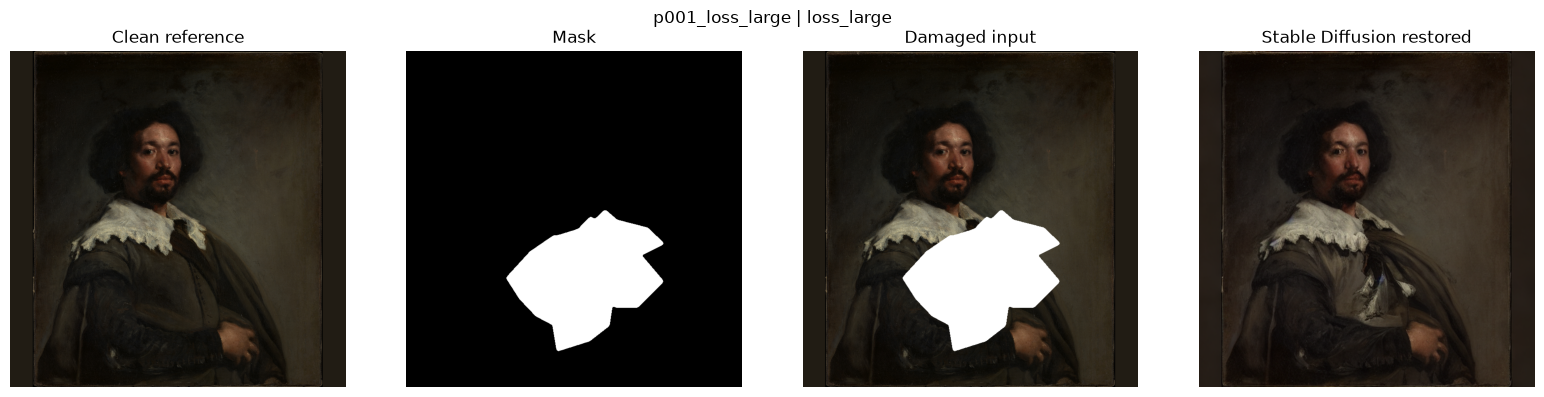

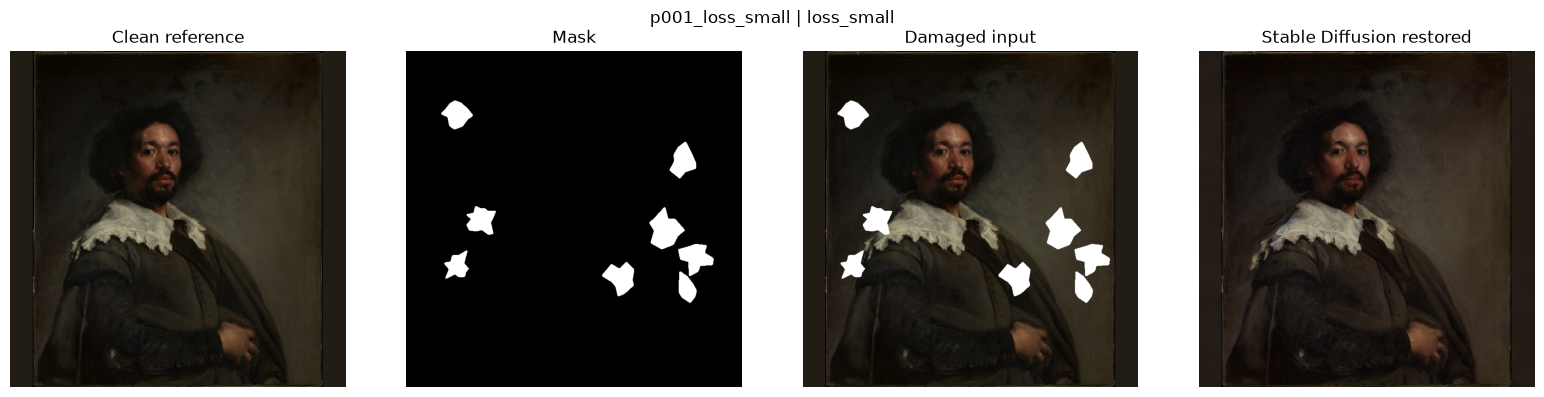

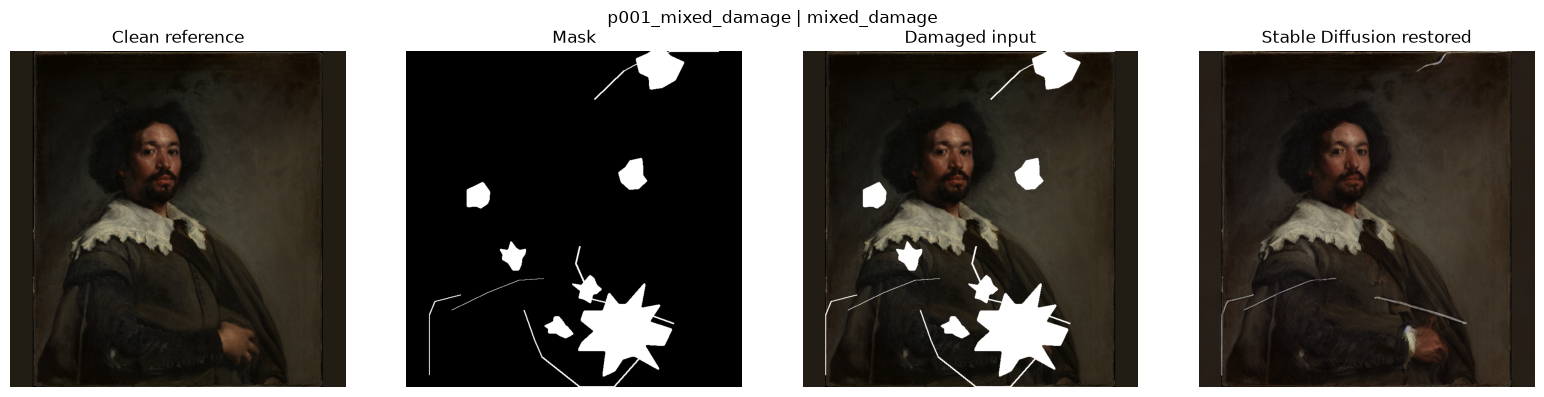

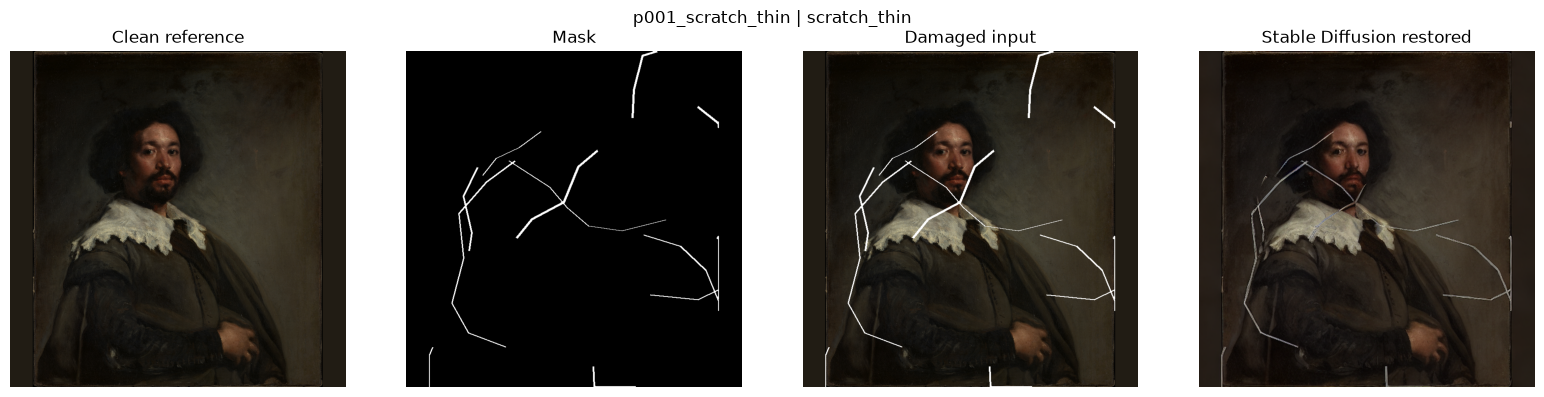

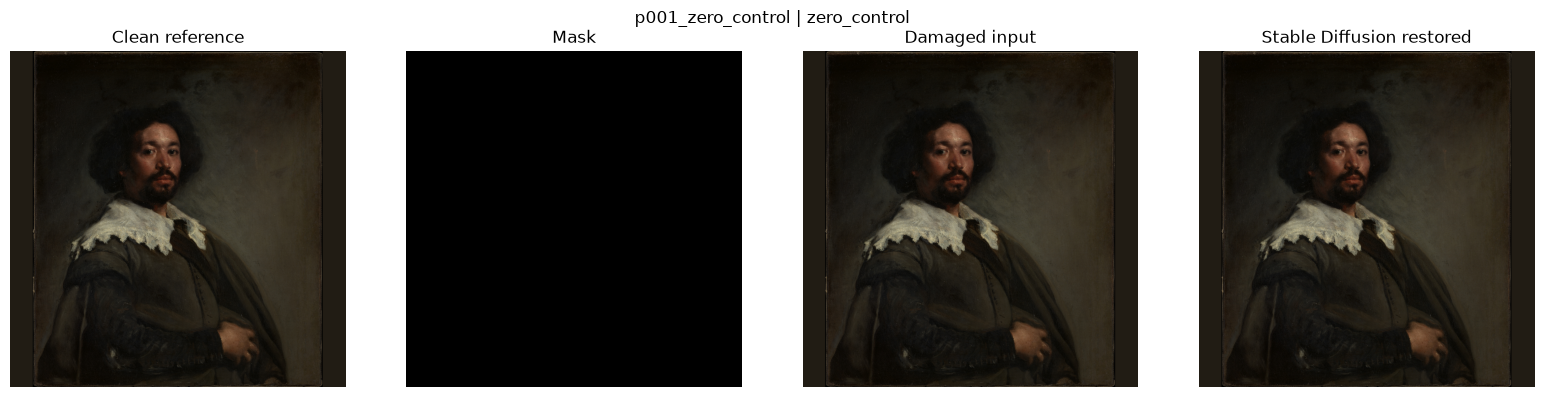

In [14]:
for _, row in one_painting_restoration_df.iterrows():
    show_smoke_case(row)

In [15]:
restored_output_dir.mkdir(parents=True, exist_ok=True)

existing_final_outputs = sorted(
    restored_output_dir.glob(f"*restored_{MODEL_NAME}.png")
)

print("Existing final Stable Diffusion outputs:", len(existing_final_outputs))

if existing_final_outputs:
    print("First existing outputs:")
    for path in existing_final_outputs[:10]:
        print(path)

    raise RuntimeError(
        "Final Stable Diffusion output directory already contains restored images. "
        "Delete or move them before running the full restoration batch."
    )

print("Final Stable Diffusion output directory is clean.")

Existing final Stable Diffusion outputs: 0
Final Stable Diffusion output directory is clean.


In [16]:
full_result = run_stable_diffusion_restoration_pipeline(
    damaged_metadata_df,
    restored_output_dir=restored_output_dir,
    project_root=PROJECT_ROOT,
    pipe=pipe,
    device=device,
    model_id=HF_MODEL_ID,
    model_name=MODEL_NAME,
    prompt=prompt,
    negative_prompt=negative_prompt,
    seed=seed,
    num_inference_steps=num_inference_steps,
    guidance_scale=guidance_scale,
    inference_size=inference_size,
    use_relative_paths=True,
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    progress_every=10,
    clear_cuda_cache_every=10,
)

stable_diffusion_restoration_df = full_result["restoration_metadata_df"]
stable_diffusion_run_info = full_result["run_info"]

print("Stable Diffusion restoration metadata shape:", stable_diffusion_restoration_df.shape)

display(
    stable_diffusion_restoration_df[
        [
            "case_id",
            "painting_id",
            "mask_type",
            "model_name",
            "inference_mode",
            "restored_path",
            "seed",
            "num_inference_steps",
            "guidance_scale",
            "inference_size",
            "case_runtime_seconds",
            "status",
            "issue",
        ]
    ].head(20)
)

print("\nRun info:")
display(pd.DataFrame([stable_diffusion_run_info]))

if torch.cuda.is_available():
    print(
        "Allocated VRAM after full run:",
        round(torch.cuda.memory_allocated() / 1024**3, 3),
        "GB",
    )
    print(
        "Reserved VRAM after full run:",
        round(torch.cuda.memory_reserved() / 1024**3, 3),
        "GB",
    )

Starting Stable Diffusion restoration pipeline
  Input rows: 250
  Valid working rows: 250
  Non-zero model inference rows: 200
  Zero-control copy rows: 50
  Restored output dir: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\restored\stable_diffusion_inpainting
  Device: cuda
  Model id: runwayml/stable-diffusion-inpainting
  Prompt: restore the missing damaged area of the painting, preserve the original style, colors, brushwork, composition, and surrounding visual context
  Negative prompt: modern objects, text, watermark, signature, frame, border, people added, face changed, extra objects, oversharpened, cartoon, digital art, photorealistic, unrealistic texture
  Seed: 2026
  Steps: 30
  Guidance scale: 7.5
  Inference size: 512
Running Stable Diffusion case 1/200
Running Stable Diffusion case 10/200
Running Stable Diffusion case 20/200
Running Stable Diffusion case 30/200
Running Stable Diffusion case 40/200
Running Stable Diffusion case 50/200
Running Stable Diffus

,case_id,painting_id,mask_type,model_name,inference_mode,restored_path,seed,num_inference_steps,guidance_scale,inference_size,case_runtime_seconds,status,issue
0,p001_loss_large,p001,loss_large,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.554261,ok,
1,p001_loss_small,p001,loss_small,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.619525,ok,
2,p001_mixed_damage,p001,mixed_damage,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.606830,ok,
3,p001_scratch_thin,p001,scratch_thin,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.153014,ok,
4,p001_zero_control,p001,zero_control,stable_diffusion_inpainting,copied_zero_control,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,0.000000,ok,zero_control copied without model inference
5,p002_loss_large,p002,loss_large,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.113144,ok,
6,p002_loss_small,p002,loss_small,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.297808,ok,
7,p002_mixed_damage,p002,mixed_damage,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.684954,ok,
8,p002_scratch_thin,p002,scratch_thin,stable_diffusion_inpainting,model_inference,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,6.664928,ok,
9,p002_zero_control,p002,zero_control,stable_diffusion_inpainting,copied_zero_control,data/processed/restored/stable_diffusion_inpai...,2026,30,7.5,512,0.000000,ok,zero_control copied without model inference



Run info:


,model_id,model_name,device,prompt,negative_prompt,seed,num_inference_steps,guidance_scale,inference_size,total_runtime_seconds,nonzero_rows,zero_control_rows
0,runwayml/stable-diffusion-inpainting,stable_diffusion_inpainting,cuda,restore the missing damaged area of the painti...,"modern objects, text, watermark, signature, fr...",2026,30,7.5,512,1793.685764,200,50


Allocated VRAM after full run: 2.029 GB
Reserved VRAM after full run: 2.053 GB


In [17]:
if len(stable_diffusion_restoration_df) != 250:
    raise ValueError(
        f"Expected 250 Stable Diffusion restoration rows, found {len(stable_diffusion_restoration_df)}."
    )

if (stable_diffusion_restoration_df["status"] != "ok").any():
    display(
        stable_diffusion_restoration_df[
            stable_diffusion_restoration_df["status"] != "ok"
        ][
            [
                "case_id",
                "painting_id",
                "mask_type",
                "status",
                "issue",
            ]
        ]
    )
    raise ValueError("Stable Diffusion restoration contains non-ok rows.")

expected_inference_counts = {
    "model_inference": 200,
    "copied_zero_control": 50,
}

actual_inference_counts = (
    stable_diffusion_restoration_df["inference_mode"]
    .value_counts()
    .to_dict()
)

print("Expected inference counts:", expected_inference_counts)
print("Actual inference counts:", actual_inference_counts)

for inference_mode, expected_count in expected_inference_counts.items():
    actual_count = actual_inference_counts.get(inference_mode, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Inference mode {inference_mode!r}: expected {expected_count}, found {actual_count}."
        )

expected_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_mask_counts = (
    stable_diffusion_restoration_df["mask_type"]
    .value_counts()
    .to_dict()
)

print("\nExpected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

stable_diffusion_restoration_df.to_csv(restored_metadata_path, index=False)

print("\nSaved Stable Diffusion restoration metadata:")
print(restored_metadata_path)

Expected inference counts: {'model_inference': 200, 'copied_zero_control': 50}
Actual inference counts: {'model_inference': 200, 'copied_zero_control': 50}

Expected mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Saved Stable Diffusion restoration metadata:
D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_stable_diffusion.csv


In [18]:
stable_diffusion_validation_df = validate_stable_diffusion_restoration_outputs(
    stable_diffusion_restoration_df,
    project_root=PROJECT_ROOT,
    expected_size=(768, 768),
    zero_control_mask_type=ZERO_CONTROL_MASK_TYPE,
    progress_every=25,
)

display(stable_diffusion_validation_df.head())

validation_counts_df = (
    stable_diffusion_validation_df["validation_passed"]
    .value_counts(dropna=False)
    .rename_axis("validation_passed")
    .reset_index(name="cases")
)

display(validation_counts_df)

if len(stable_diffusion_validation_df) != 250:
    raise ValueError(
        f"Expected 250 validation rows, found {len(stable_diffusion_validation_df)}."
    )

if not stable_diffusion_validation_df["validation_passed"].all():
    display(
        stable_diffusion_validation_df[
            ~stable_diffusion_validation_df["validation_passed"]
        ]
    )
    raise ValueError("Stable Diffusion full-output validation failed.")

stable_diffusion_validation_df.to_csv(validation_summary_path, index=False)

print("Saved Stable Diffusion validation summary:")
print(validation_summary_path)

print("\nStable Diffusion full-output validation passed.")

Validating Stable Diffusion restored outputs: 250 rows
Validating Stable Diffusion output 1/250
Validating Stable Diffusion output 25/250
Validating Stable Diffusion output 50/250
Validating Stable Diffusion output 75/250
Validating Stable Diffusion output 100/250
Validating Stable Diffusion output 125/250
Validating Stable Diffusion output 150/250
Validating Stable Diffusion output 175/250
Validating Stable Diffusion output 200/250
Validating Stable Diffusion output 225/250
Validating Stable Diffusion output 250/250
Stable Diffusion validation complete
validation_passed
True    250


,case_id,painting_id,mask_type,status,damaged_exists,restored_exists,restored_width,restored_height,restored_mode,exact_match_to_damaged,changed_from_damaged,max_abs_diff,mean_abs_diff,validation_passed,validation_issue
0,p001_loss_large,p001,loss_large,ok,True,True,768,768,RGB,False,True,255.0,27.888373,True,
1,p001_loss_small,p001,loss_small,ok,True,True,768,768,RGB,False,True,253.0,12.474539,True,
2,p001_mixed_damage,p001,mixed_damage,ok,True,True,768,768,RGB,False,True,255.0,20.871865,True,
3,p001_scratch_thin,p001,scratch_thin,ok,True,True,768,768,RGB,False,True,255.0,6.959231,True,
4,p001_zero_control,p001,zero_control,ok,True,True,768,768,RGB,True,False,0.0,0.000000,True,


,validation_passed,cases
0,True,250


Saved Stable Diffusion validation summary:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_restoration_validation_summary_50.csv

Stable Diffusion full-output validation passed.


In [19]:
stable_diffusion_summaries = summarize_stable_diffusion_restoration_metadata(
    stable_diffusion_restoration_df
)

overview_summary_df = stable_diffusion_summaries["overview_df"]
by_mask_type_summary_df = stable_diffusion_summaries["by_mask_type_df"]
by_inference_mode_summary_df = stable_diffusion_summaries["by_inference_mode_df"]

overview_summary_df.to_csv(overview_summary_path, index=False)
by_mask_type_summary_df.to_csv(by_mask_type_summary_path, index=False)
by_inference_mode_summary_df.to_csv(by_inference_mode_summary_path, index=False)

print("Overview summary:")
display(overview_summary_df)

print("\nSummary by mask type:")
display(by_mask_type_summary_df)

print("\nSummary by inference mode:")
display(by_inference_mode_summary_df)

print("\nSaved restoration summaries:")
print(overview_summary_path)
print(by_mask_type_summary_path)
print(by_inference_mode_summary_path)

Overview summary:


,item,value
0,total_rows,250.000000
1,unique_paintings,50.000000
2,successful_rows,250.000000
3,error_rows,0.000000
4,model_inference_rows,200.000000
5,copied_zero_control_rows,50.000000
6,mean_case_runtime_seconds,8.397577



Summary by mask type:


,mask_type,cases,successful_cases,error_cases,mean_case_runtime_seconds
0,loss_large,50,50,0,8.42782
1,loss_small,50,50,0,8.41522
2,mixed_damage,50,50,0,8.38019
3,scratch_thin,50,50,0,8.36708
4,zero_control,50,50,0,0.00000



Summary by inference mode:


,inference_mode,cases,successful_cases,error_cases,mean_case_runtime_seconds
0,copied_zero_control,50,50,0,0.00000
1,model_inference,200,200,0,8.39758



Saved restoration summaries:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_restoration_overview_summary_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_restoration_by_mask_type_summary_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_restoration_by_inference_mode_summary_50.csv


In [20]:
processed_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

if not processed_metadata_path.exists():
    raise FileNotFoundError(f"Processed metadata not found: {processed_metadata_path}")

processed_metadata_df = pd.read_csv(processed_metadata_path)

metadata_columns = [
    "painting_id",
    "title",
    "artist",
    "date",
    "category",
    "style_or_period",
    "medium",
    "source",
    "source_url",
    "license",
    "filename",
]

missing_metadata_columns = [
    column for column in metadata_columns
    if column not in processed_metadata_df.columns
]

if missing_metadata_columns:
    raise ValueError(
        f"Processed metadata missing columns: {missing_metadata_columns}"
    )

stable_diffusion_visual_df = stable_diffusion_restoration_df.merge(
    processed_metadata_df[metadata_columns],
    on="painting_id",
    how="left",
    validate="many_to_one",
)

if stable_diffusion_visual_df["category"].isna().any():
    raise ValueError("Visual inspection metadata contains missing category values.")

print("Visual metadata shape:", stable_diffusion_visual_df.shape)

print("\nCategory counts:")
display(stable_diffusion_visual_df["category"].value_counts().sort_index())

print("\nMask counts:")
display(stable_diffusion_visual_df["mask_type"].value_counts().sort_index())

Visual metadata shape: (250, 46)

Category counts:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64


Mask counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64

In [21]:
nonzero_visual_df = stable_diffusion_visual_df[
    stable_diffusion_visual_df["mask_type"] != ZERO_CONTROL_MASK_TYPE
].copy()

# One representative per category and mask type where possible.
category_mask_examples_df = (
    nonzero_visual_df
    .sort_values(["category", "mask_type", "painting_id"])
    .groupby(["category", "mask_type"], dropna=False)
    .head(1)
    .copy()
)

category_mask_examples_df["selection_reason"] = "Representative category-mask example"

# Add zero-control examples for sanity inspection.
zero_control_examples_df = (
    stable_diffusion_visual_df[
        stable_diffusion_visual_df["mask_type"] == ZERO_CONTROL_MASK_TYPE
    ]
    .sort_values(["category", "painting_id"])
    .groupby("category", dropna=False)
    .head(1)
    .copy()
)

zero_control_examples_df["selection_reason"] = "Zero-control sanity example"

stable_diffusion_selected_visual_df = pd.concat(
    [
        category_mask_examples_df,
        zero_control_examples_df,
    ],
    ignore_index=True,
)

stable_diffusion_selected_visual_df = (
    stable_diffusion_selected_visual_df
    .sort_values(["category", "mask_type", "painting_id"])
    .reset_index(drop=True)
)

stable_diffusion_selected_visual_df.to_csv(
    visual_inspection_manifest_path,
    index=False,
)

print("Selected visual inspection cases:", len(stable_diffusion_selected_visual_df))
print("Saved visual inspection manifest:")
print(visual_inspection_manifest_path)

display(
    stable_diffusion_selected_visual_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "selection_reason",
            "inference_mode",
            "restored_path",
        ]
    ]
)

Selected visual inspection cases: 25
Saved visual inspection manifest:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_selected_visual_inspection_manifest_50.csv


,case_id,painting_id,category,title,mask_type,selection_reason,inference_mode,restored_path
0,p031_loss_large,p031,abstraction_surrealism,Improvisation No. 30 (Cannons),loss_large,Representative category-mask example,model_inference,data/processed/restored/stable_diffusion_inpai...
1,p031_loss_small,p031,abstraction_surrealism,Improvisation No. 30 (Cannons),loss_small,Representative category-mask example,model_inference,data/processed/restored/stable_diffusion_inpai...
2,p031_mixed_damage,p031,abstraction_surrealism,Improvisation No. 30 (Cannons),mixed_damage,Representative category-mask example,model_inference,data/processed/restored/stable_diffusion_inpai...
3,p031_scratch_thin,p031,abstraction_surrealism,Improvisation No. 30 (Cannons),scratch_thin,Representative category-mask example,model_inference,data/processed/restored/stable_diffusion_inpai...
4,p031_zero_control,p031,abstraction_surrealism,Improvisation No. 30 (Cannons),zero_control,Zero-control sanity example,copied_zero_control,data/processed/restored/stable_diffusion_inpai...
5,p021_loss_large,p021,architecture_structured,Interior of the Oude Kerk in Delft,loss_large,Representative category-mask example,model_inference,data/processed/restored/stable_diffusion_inpai...
6,p021_loss_small,p021,architecture_structured,Interior of the Oude Kerk in Delft,loss_small,Representative category-mask example,model_inference,data/processed/restored/stable_diffusion_inpai...
7,p021_mixed_damage,p021,architecture_structured,Interior of the Oude Kerk in Delft,mixed_damage,Representative category-mask example,model_inference,data/processed/restored/stable_diffusion_inpai...
8,p021_scratch_thin,p021,architecture_structured,Interior of the Oude Kerk in Delft,scratch_thin,Representative category-mask example,model_inference,data/processed/restored/stable_diffusion_inpai...
9,p021_zero_control,p021,architecture_structured,Interior of the Oude Kerk in Delft,zero_control,Zero-control sanity example,copied_zero_control,data/processed/restored/stable_diffusion_inpai...


In [22]:
def load_project_rgb(path_value: str | Path) -> Image.Image:
    path = resolve_project_path(path_value)

    if not path.exists():
        raise FileNotFoundError(f"Missing image file: {path}")

    return Image.open(path).convert("RGB")


def load_project_mask(path_value: str | Path) -> Image.Image:
    path = resolve_project_path(path_value)

    if not path.exists():
        raise FileNotFoundError(f"Missing mask file: {path}")

    return Image.open(path).convert("L")


def save_stable_diffusion_visual_inspection_figure(
    row: pd.Series,
    *,
    output_dir: Path,
) -> Path:
    clean_img = load_project_rgb(row["clean_path"])
    damaged_img = load_project_rgb(row["damaged_path"])
    mask_img = load_project_mask(row["mask_path"])
    restored_img = load_project_rgb(row["restored_path"])

    figure_path = output_dir / f"{row['case_id']}_stable_diffusion_restoration.png"

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(clean_img)
    axes[0].set_title("Clean reference")
    axes[0].axis("off")

    axes[1].imshow(mask_img, cmap="gray")
    axes[1].set_title("Mask")
    axes[1].axis("off")

    axes[2].imshow(damaged_img)
    axes[2].set_title("Damaged input")
    axes[2].axis("off")

    axes[3].imshow(restored_img)
    axes[3].set_title("Stable Diffusion restored")
    axes[3].axis("off")

    fig.suptitle(
        f"{row['case_id']} | {row['category']} | {row['mask_type']}",
        fontsize=12,
    )

    plt.tight_layout()
    fig.savefig(figure_path, dpi=140, bbox_inches="tight")
    plt.close(fig)

    return figure_path


print("Stable Diffusion visual inspection helper ready.")

Stable Diffusion visual inspection helper ready.


In [23]:
visual_figure_paths = []

for index, row in stable_diffusion_selected_visual_df.iterrows():
    figure_path = save_stable_diffusion_visual_inspection_figure(
        row,
        output_dir=visual_inspection_dir,
    )

    visual_figure_paths.append(str(figure_path))

    if (index + 1) % 5 == 0 or (index + 1) == len(stable_diffusion_selected_visual_df):
        print(
            f"Generated {index + 1}/{len(stable_diffusion_selected_visual_df)} "
            "Stable Diffusion visual inspection figures..."
        )

stable_diffusion_selected_visual_df["visual_figure_path"] = visual_figure_paths

stable_diffusion_selected_visual_df.to_csv(
    visual_inspection_manifest_path,
    index=False,
)

print("\nSaved updated visual inspection manifest:")
print(visual_inspection_manifest_path)

print("Generated visual inspection figures:", len(visual_figure_paths))
print("Visual inspection directory:", visual_inspection_dir)

display(
    stable_diffusion_selected_visual_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "visual_figure_path",
        ]
    ].head(25)
)

Generated 5/25 Stable Diffusion visual inspection figures...
Generated 10/25 Stable Diffusion visual inspection figures...
Generated 15/25 Stable Diffusion visual inspection figures...
Generated 20/25 Stable Diffusion visual inspection figures...
Generated 25/25 Stable Diffusion visual inspection figures...

Saved updated visual inspection manifest:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_selected_visual_inspection_manifest_50.csv
Generated visual inspection figures: 25
Visual inspection directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\stable_diffusion_restoration_selected_cases


,case_id,category,mask_type,selection_reason,visual_figure_path
0,p031_loss_large,abstraction_surrealism,loss_large,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p031_loss_small,abstraction_surrealism,loss_small,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p031_mixed_damage,abstraction_surrealism,mixed_damage,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p031_scratch_thin,abstraction_surrealism,scratch_thin,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p031_zero_control,abstraction_surrealism,zero_control,Zero-control sanity example,D:\Masters\FH\Thesis\painting-restoration-eval...
5,p021_loss_large,architecture_structured,loss_large,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
6,p021_loss_small,architecture_structured,loss_small,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
7,p021_mixed_damage,architecture_structured,mixed_damage,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
8,p021_scratch_thin,architecture_structured,scratch_thin,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
9,p021_zero_control,architecture_structured,zero_control,Zero-control sanity example,D:\Masters\FH\Thesis\painting-restoration-eval...


In [24]:
expected_output_files = [
    restored_metadata_path,
    overview_summary_path,
    by_mask_type_summary_path,
    by_inference_mode_summary_path,
    validation_summary_path,
    visual_inspection_manifest_path,
]

for output_file in expected_output_files:
    if not output_file.exists():
        raise FileNotFoundError(f"Missing expected output file: {output_file}")

saved_restoration_df = pd.read_csv(restored_metadata_path)
saved_visual_manifest_df = pd.read_csv(visual_inspection_manifest_path)

if len(saved_restoration_df) != 250:
    raise ValueError(
        f"Expected 250 saved restoration rows, found {len(saved_restoration_df)}."
    )

if len(saved_visual_manifest_df) != len(stable_diffusion_selected_visual_df):
    raise ValueError(
        "Saved visual inspection manifest row count does not match selected dataframe."
    )

missing_visual_figures = [
    path
    for path in saved_visual_manifest_df["visual_figure_path"]
    if str(path).strip() == "" or not Path(path).exists()
]

if missing_visual_figures:
    raise FileNotFoundError(
        f"Missing Stable Diffusion visual inspection figures: {missing_visual_figures[:10]}"
    )

if (saved_restoration_df["status"] != "ok").any():
    raise ValueError("Saved Stable Diffusion restoration metadata contains non-ok rows.")

expected_saved_inference_counts = {
    "model_inference": 200,
    "copied_zero_control": 50,
}

actual_saved_inference_counts = (
    saved_restoration_df["inference_mode"]
    .value_counts()
    .to_dict()
)

for inference_mode, expected_count in expected_saved_inference_counts.items():
    actual_count = actual_saved_inference_counts.get(inference_mode, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved inference mode {inference_mode!r}: "
            f"expected {expected_count}, found {actual_count}."
        )

print("Saved restoration metadata rows:", len(saved_restoration_df))
print("Saved visual inspection rows:", len(saved_visual_manifest_df))
print("Stable Diffusion restoration summary and visual outputs passed validation.")

Saved restoration metadata rows: 250
Saved visual inspection rows: 25
Stable Diffusion restoration summary and visual outputs passed validation.


Displaying visual inspection sample figures: 6


,case_id,category,title,mask_type,selection_reason,visual_figure_path
0,p031_loss_large,abstraction_surrealism,Improvisation No. 30 (Cannons),loss_large,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p021_loss_large,architecture_structured,Interior of the Oude Kerk in Delft,loss_large,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p041_loss_large,high_texture_brushwork,Wheat Field with Cypresses,loss_large,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p011_loss_large,landscape_natural,View of Haarlem and the Haarlemmer Meer,loss_large,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p001_loss_large,portrait_figure,Juan de Pareja,loss_large,Representative category-mask example,D:\Masters\FH\Thesis\painting-restoration-eval...
5,p031_zero_control,abstraction_surrealism,Improvisation No. 30 (Cannons),zero_control,Zero-control sanity example,D:\Masters\FH\Thesis\painting-restoration-eval...


Displaying p031_loss_large | abstraction_surrealism | loss_large


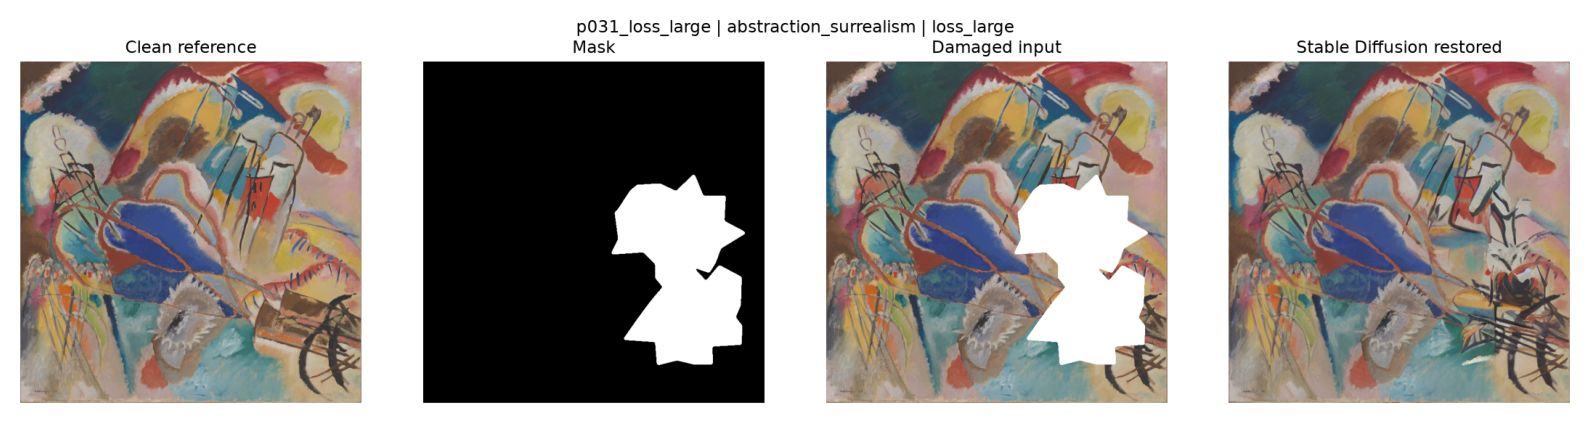

Displaying p021_loss_large | architecture_structured | loss_large


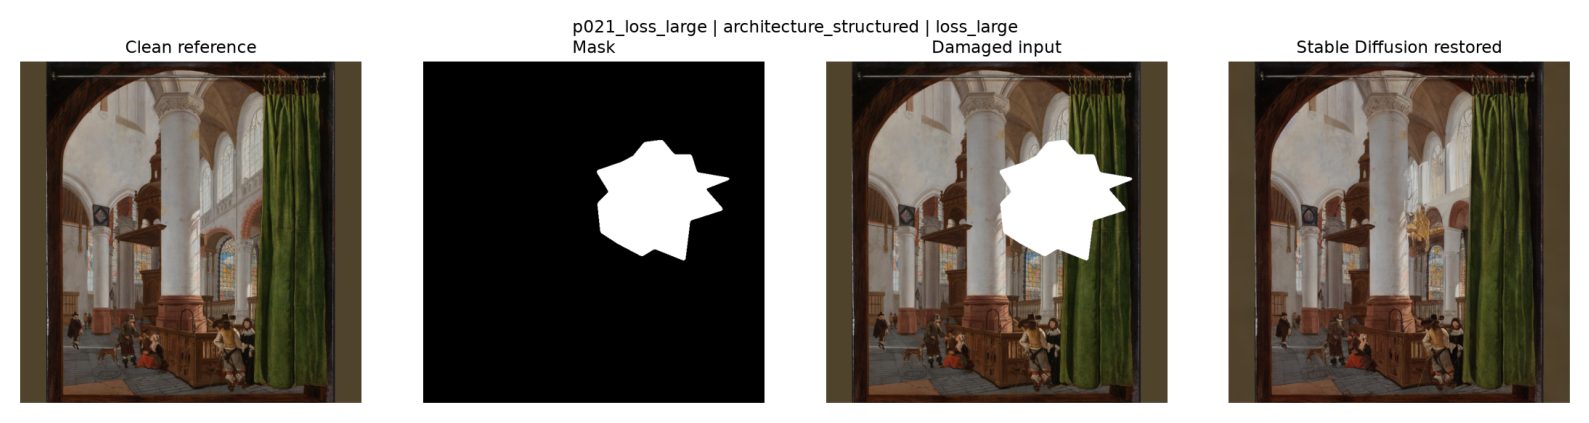

Displaying p041_loss_large | high_texture_brushwork | loss_large


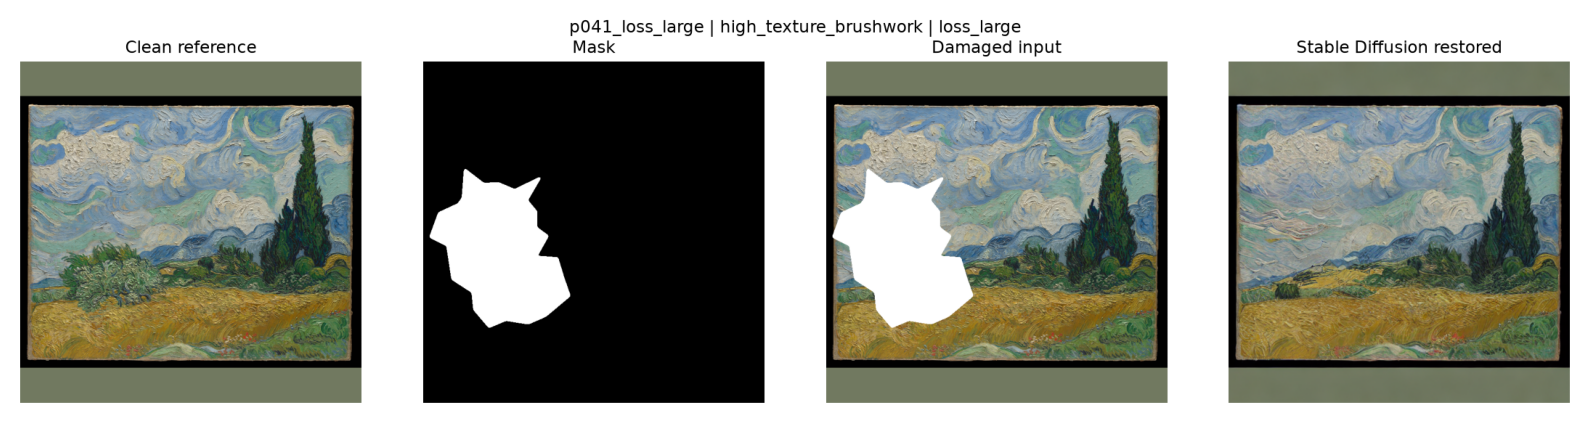

Displaying p011_loss_large | landscape_natural | loss_large


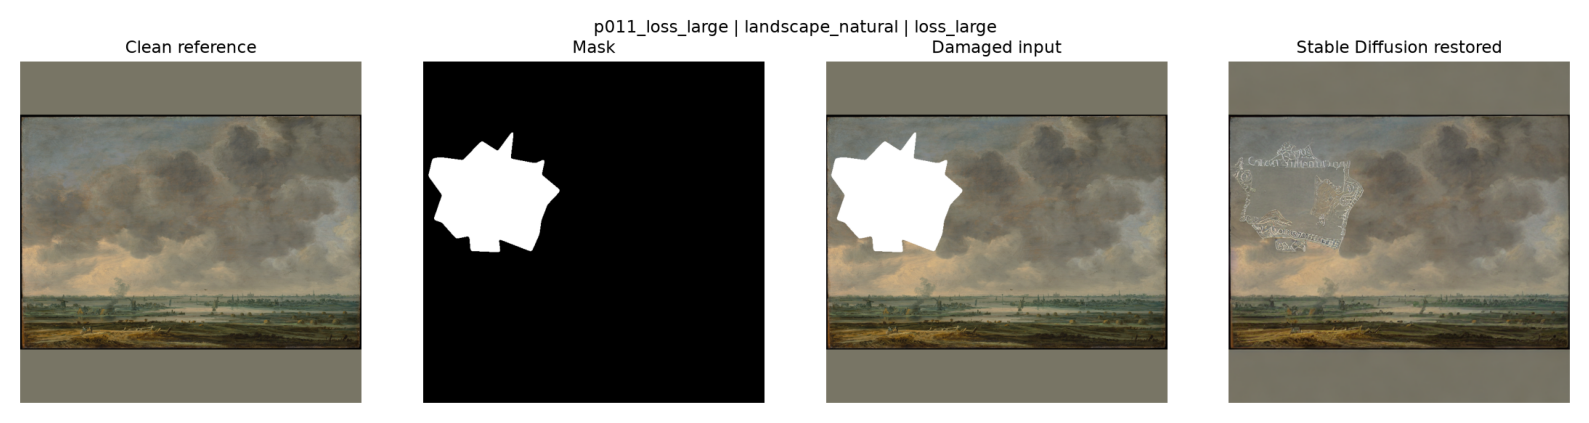

Displaying p001_loss_large | portrait_figure | loss_large


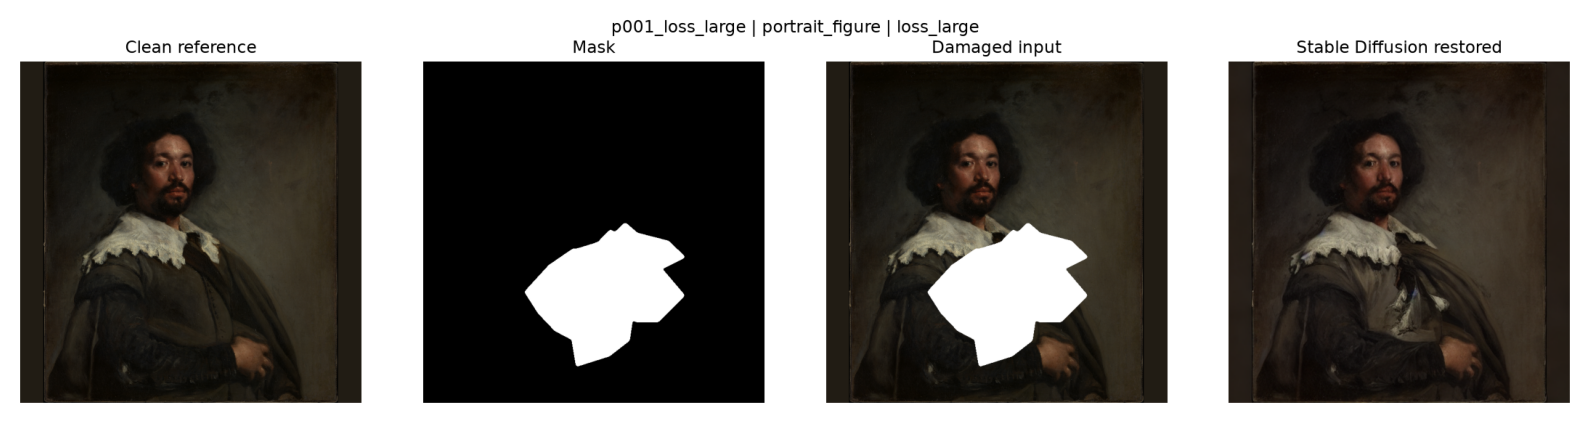

Displaying p031_zero_control | abstraction_surrealism | zero_control


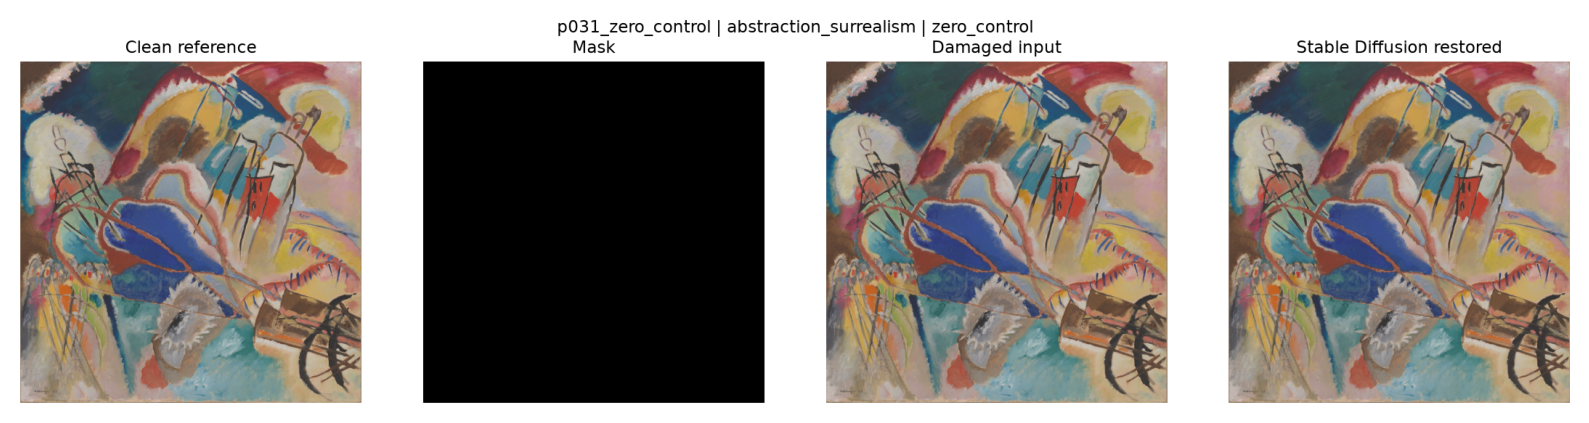

In [25]:
def display_saved_visual_figure(path_value: str | Path) -> None:
    figure_path = Path(path_value)

    if not figure_path.exists():
        raise FileNotFoundError(f"Missing visual figure: {figure_path}")

    figure_img = Image.open(figure_path).convert("RGB")

    plt.figure(figsize=(16, 7))
    plt.imshow(figure_img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Display a compact but diverse sample:
# - one non-zero example per category where possible
# - plus one zero-control sanity case
sample_nonzero_visual_df = (
    stable_diffusion_selected_visual_df[
        stable_diffusion_selected_visual_df["mask_type"] != ZERO_CONTROL_MASK_TYPE
    ]
    .sort_values(["category", "mask_type", "painting_id"])
    .groupby("category", dropna=False)
    .head(1)
    .copy()
)

sample_zero_visual_df = (
    stable_diffusion_selected_visual_df[
        stable_diffusion_selected_visual_df["mask_type"] == ZERO_CONTROL_MASK_TYPE
    ]
    .sort_values(["category", "painting_id"])
    .head(1)
    .copy()
)

sample_visual_display_df = pd.concat(
    [sample_nonzero_visual_df, sample_zero_visual_df],
    ignore_index=True,
)

print("Displaying visual inspection sample figures:", len(sample_visual_display_df))

display(
    sample_visual_display_df[
        [
            "case_id",
            "category",
            "title",
            "mask_type",
            "selection_reason",
            "visual_figure_path",
        ]
    ]
)

for _, row in sample_visual_display_df.iterrows():
    print(
        f"Displaying {row['case_id']} | "
        f"{row['category']} | {row['mask_type']}"
    )
    display_saved_visual_figure(row["visual_figure_path"])

In [26]:
expected_final_files = [
    restored_metadata_path,
    overview_summary_path,
    by_mask_type_summary_path,
    by_inference_mode_summary_path,
    validation_summary_path,
    visual_inspection_manifest_path,
]

for output_file in expected_final_files:
    if not output_file.exists():
        raise FileNotFoundError(f"Missing expected Stable Diffusion output: {output_file}")

saved_restoration_df = pd.read_csv(restored_metadata_path)
saved_overview_df = pd.read_csv(overview_summary_path)
saved_by_mask_type_df = pd.read_csv(by_mask_type_summary_path)
saved_by_inference_mode_df = pd.read_csv(by_inference_mode_summary_path)
saved_validation_df = pd.read_csv(validation_summary_path)
saved_visual_manifest_df = pd.read_csv(visual_inspection_manifest_path)

if len(saved_restoration_df) != 250:
    raise ValueError(
        f"Expected 250 saved restoration rows, found {len(saved_restoration_df)}."
    )

if len(saved_validation_df) != 250:
    raise ValueError(
        f"Expected 250 saved validation rows, found {len(saved_validation_df)}."
    )

if not saved_validation_df["validation_passed"].all():
    display(saved_validation_df[~saved_validation_df["validation_passed"]])
    raise ValueError("Saved Stable Diffusion validation summary contains failed rows.")

if (saved_restoration_df["status"] != "ok").any():
    display(saved_restoration_df[saved_restoration_df["status"] != "ok"])
    raise ValueError("Saved Stable Diffusion restoration metadata contains non-ok rows.")

expected_final_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_final_mask_counts = saved_restoration_df["mask_type"].value_counts().to_dict()

print("Expected final mask counts:", expected_final_mask_counts)
print("Actual final mask counts:", actual_final_mask_counts)

for mask_type, expected_count in expected_final_mask_counts.items():
    actual_count = actual_final_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Final mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_final_inference_counts = {
    "model_inference": 200,
    "copied_zero_control": 50,
}

actual_final_inference_counts = saved_restoration_df["inference_mode"].value_counts().to_dict()

print("\nExpected final inference counts:", expected_final_inference_counts)
print("Actual final inference counts:", actual_final_inference_counts)

for inference_mode, expected_count in expected_final_inference_counts.items():
    actual_count = actual_final_inference_counts.get(inference_mode, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Final inference mode {inference_mode!r}: "
            f"expected {expected_count}, found {actual_count}."
        )

required_restoration_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "model_name",
    "restoration_method",
    "hf_model_id",
    "inference_mode",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
    "prompt",
    "negative_prompt",
    "seed",
    "num_inference_steps",
    "guidance_scale",
    "inference_size",
    "status",
    "issue",
]

missing_restoration_columns = [
    column for column in required_restoration_columns
    if column not in saved_restoration_df.columns
]

if missing_restoration_columns:
    raise ValueError(
        f"Saved Stable Diffusion metadata missing required columns: "
        f"{missing_restoration_columns}"
    )

if set(saved_restoration_df["model_name"].dropna().unique()) != {MODEL_NAME}:
    raise ValueError(
        f"Unexpected model names: {saved_restoration_df['model_name'].unique()}"
    )

if set(saved_restoration_df["hf_model_id"].dropna().unique()) != {HF_MODEL_ID}:
    raise ValueError(
        f"Unexpected HF model ids: {saved_restoration_df['hf_model_id'].unique()}"
    )

if set(saved_restoration_df["seed"].dropna().unique()) != {seed}:
    raise ValueError(
        f"Unexpected seeds: {saved_restoration_df['seed'].unique()}"
    )

if set(saved_restoration_df["num_inference_steps"].dropna().unique()) != {num_inference_steps}:
    raise ValueError(
        "Unexpected num_inference_steps values: "
        f"{saved_restoration_df['num_inference_steps'].unique()}"
    )

if set(saved_restoration_df["guidance_scale"].dropna().unique()) != {guidance_scale}:
    raise ValueError(
        f"Unexpected guidance_scale values: {saved_restoration_df['guidance_scale'].unique()}"
    )

if set(saved_restoration_df["inference_size"].dropna().unique()) != {inference_size}:
    raise ValueError(
        f"Unexpected inference_size values: {saved_restoration_df['inference_size'].unique()}"
    )

missing_restored_files = [
    resolve_project_path(path)
    for path in saved_restoration_df["restored_path"]
    if str(path).strip() == "" or not resolve_project_path(path).exists()
]

if missing_restored_files:
    raise FileNotFoundError(
        f"Saved restoration metadata references missing restored files: "
        f"{missing_restored_files[:10]}"
    )

if len(saved_visual_manifest_df) != 25:
    raise ValueError(
        f"Expected 25 visual inspection rows, found {len(saved_visual_manifest_df)}."
    )

missing_visual_figures = [
    Path(path)
    for path in saved_visual_manifest_df["visual_figure_path"]
    if str(path).strip() == "" or not Path(path).exists()
]

if missing_visual_figures:
    raise FileNotFoundError(
        f"Saved visual manifest references missing figures: {missing_visual_figures[:10]}"
    )

print("\nSaved overview rows:", len(saved_overview_df))
print("Saved by-mask summary rows:", len(saved_by_mask_type_df))
print("Saved by-inference-mode summary rows:", len(saved_by_inference_mode_df))
print("Saved visual inspection rows:", len(saved_visual_manifest_df))
print("Final Stable Diffusion restoration output gates passed.")

Expected final mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual final mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Expected final inference counts: {'model_inference': 200, 'copied_zero_control': 50}
Actual final inference counts: {'model_inference': 200, 'copied_zero_control': 50}

Saved overview rows: 7
Saved by-mask summary rows: 5
Saved by-inference-mode summary rows: 2
Saved visual inspection rows: 25
Final Stable Diffusion restoration output gates passed.


## Notebook 18 summary

This notebook generated Stable Diffusion Inpainting restoration outputs for the controlled 50-painting subset.

The baseline used:

- model: `runwayml/stable-diffusion-inpainting`,
- model name: `stable_diffusion_inpainting`,
- fixed seed: `2026`,
- inference steps: `30`,
- guidance scale: `7.5`,
- inference size: `512 × 512`.

A fixed prompt and fixed negative prompt were used for all paintings to reduce prompt-engineering bias.

The final restoration output contains 250 rows:

- 200 non-zero damage cases processed through Stable Diffusion Inpainting,
- 50 zero-control cases copied directly from the damaged input.

Main outputs:

- `data/processed/restored/stable_diffusion_inpainting/`
- `data/processed/metadata/metadata_restored_stable_diffusion.csv`
- `outputs/metrics/stable_diffusion_restoration_overview_summary_50.csv`
- `outputs/metrics/stable_diffusion_restoration_by_mask_type_summary_50.csv`
- `outputs/metrics/stable_diffusion_restoration_by_inference_mode_summary_50.csv`
- `outputs/metrics/stable_diffusion_restoration_validation_summary_50.csv`
- `outputs/metrics/stable_diffusion_selected_visual_inspection_manifest_50.csv`
- `outputs/figures/stable_diffusion_restoration_selected_cases/`

The restored outputs were validated for file existence, expected image size, zero-control identity, and non-zero change from damaged input.

This stage completes Stable Diffusion restoration generation and prepares the model for the same metric stack already applied to OpenCV Telea and LaMa.